<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [2]:
# Your code here
college =pd.read_csv('./data/College.csv')

#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [3]:
# Your code here
college.shape

(777, 19)

In [4]:
college.describe

<bound method NDFrame.describe of                          Unnamed: 0 Private   Apps  Accept  Enroll  Top10perc  \
0      Abilene Christian University     Yes   1660    1232     721         23   
1                Adelphi University     Yes   2186    1924     512         16   
2                    Adrian College     Yes   1428    1097     336         22   
3               Agnes Scott College     Yes    417     349     137         60   
4         Alaska Pacific University     Yes    193     146      55         16   
..                              ...     ...    ...     ...     ...        ...   
772         Worcester State College      No   2197    1515     543          4   
773               Xavier University     Yes   1959    1805     695         24   
774  Xavier University of Louisiana     Yes   2097    1915     695         34   
775                 Yale University     Yes  10705    2453    1317         95   
776    York College of Pennsylvania     Yes   2989    1855     691         

In [5]:
college.isna().sum()

Unnamed: 0     0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [6]:
college['PhD'].describe()

count     777
unique     78
top         ?
freq       29
Name: PhD, dtype: object

In [7]:
college['PhD'] = college['PhD'].replace("?", None)

In [8]:
# Your code here
college['PhD'] =  pd.to_numeric(college['PhD'])

In [60]:
college['PhD'] = college['PhD'].fillna(college['PhD'].median())

In [61]:
college['PhD'].unique()

array([ 70.,  29.,  53.,  92.,  76.,  75.,  90.,  89.,  79.,  40.,  82.,
        73.,  60.,  36.,  78.,  48.,  62.,  69.,  83.,  55.,  88.,  57.,
        93.,  85.,  65.,  66.,  81.,  59.,  58.,  68.,  98.,  71.,  74.,
        61.,  35.,  87.,  80.,  63.,  39.,  99., 100.,  95.,  77.,  72.,
        64.,  10.,  86.,  22.,  50.,  41.,   8.,  67.,  94.,  56.,  46.,
        54.,  84.,  97.,  51.,  42.,  49.,  52.,  43.,  37.,  45.,  47.,
        91.,  31.,  96.,  34.,  33.,  44.,  32.,  14., 103.,  26.,  16.])

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [62]:
# Your code here
college['Grad.Rate'].describe()

count    777.000000
mean      65.440154
std       17.118804
min       10.000000
25%       53.000000
50%       65.000000
75%       78.000000
max      100.000000
Name: Grad.Rate, dtype: float64

In [63]:
college['Grad.Rate'] = college['Grad.Rate'].clip(upper=100)

In [64]:
college['Grad.Rate']

0      60
1      56
2      54
3      59
4      15
       ..
772    40
773    83
774    49
775    99
776    99
Name: Grad.Rate, Length: 777, dtype: int64

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [65]:
%%writefile  myutils.py
import numpy
import pandas as pd
def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    # Your code here 

    results = []

    numeric_cols = df.select_dtypes(include = [numpy.number]).columns

    for col in numeric_cols:
        skew_value = df[col].skew()
        min_value = df[col].min()
        
        if skew_value < -1:
            degree= "Highly Skewed"
            direction ="Left"
        
        elif -1 <= skew_value <= -0.5:
            degree = "Moderately Skewed"
            direction ="Left"
        
        
        elif -0.5 <= skew_value <= 0.5:
            degree = "Normal"
            direction = "Symmetrical" 
            
        elif  0.5 <= skew_value <=1:
            degree = 'Moderately Skewed'
            direction ='Right'

        elif skew_value > 1:
            degree = "Highly Skewed"
            direction = "Right"

        if degree == "Normal":
            rec_transformation = "None"
            
        
        elif min_value < 0:
            rec_transformation = "Yeo-Johnson" 
        elif min_value >0:
            rec_transformation = "Box-Cox or Yeo-Johnson"
        else:
            rec_transformation = "Log Plus One or Yeo-Johnson"

        results.append({
        "feature": col,
        "skewness" : skew_value,
        "degree" : degree,
        "direction": direction,
        "recommended trans" : rec_transformation
        })

    return pd.DataFrame(results)

Overwriting myutils.py


In [66]:
from myutils import skew_calc

skew_table = skew_calc(college)
skew_table

,feature,skewness,degree,direction,recommended trans
0,Apps,3.723750,Highly Skewed,Right,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Right,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Right,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Right,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Normal,Symmetrical,None
5,F.Undergrad,2.610458,Highly Skewed,Right,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Right,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Right,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Normal,Symmetrical,None
9,Books,3.485025,Highly Skewed,Right,Box-Cox or Yeo-Johnson


In [67]:
# Now import the function from myutils
from myutils import skew_calc

In [68]:
def plot_transformations(df, skew_table):
    
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
# Your code here

    to_transform = skew_table[skew_table["recommended trans"] !="None"]
    for _, row in to_transform.iterrows():
        col_name = row["feature"]           
        method = row["recommended trans"] 

        if 'Yeo-Johnson' in method:
            pt_yeo= PowerTransformer(method = 'yeo-johnson')
            transformed = pt_yeo.fit_transform(df[row['feature']].values.reshape(-1, 1)).flatten()
    
        elif 'Log Plus One' in method:
            transformed = np.log1p(df[row['feature']])
            
        elif 'Box-Cox' in method:
            pt_boxcox = PowerTransformer(method='box-cox')
            transformed = pt_boxcox.fit_transform(df[row['feature']].values.reshape(-1, 1)).flatten()
        else:
            transformed = None
    
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(df[row['feature']], kde=True, ax=axs[0], color='steelblue')
        axs[0].set_title(f"Origninal (Before) {col_name}\n(Skew: {round(df[row['feature']].skew(), 2)})")

        sns.histplot(transformed, kde=True, ax=axs[1], color='steelblue')
        axs[1].set_title(f"Best transformation (after): {method} for {col_name}\nSkew: {round(pd.Series(transformed).skew(), 2)})")

        plt.tight_layout()
        plt.show()

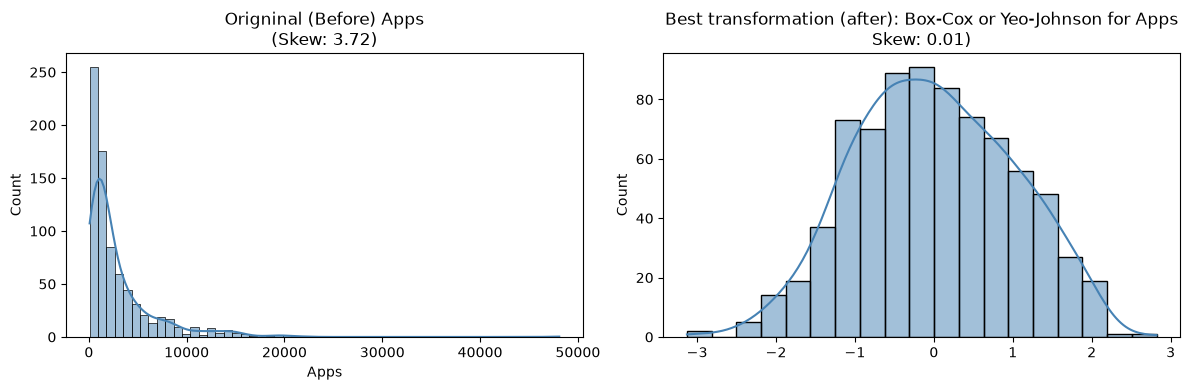

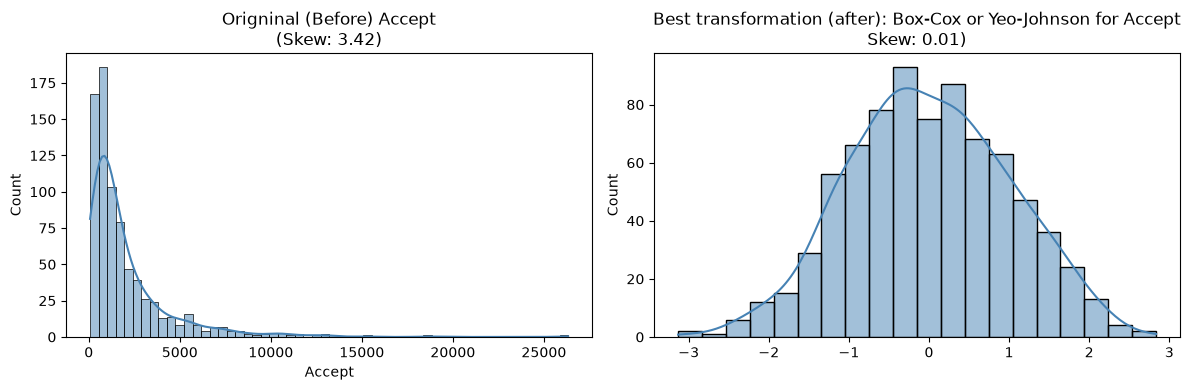

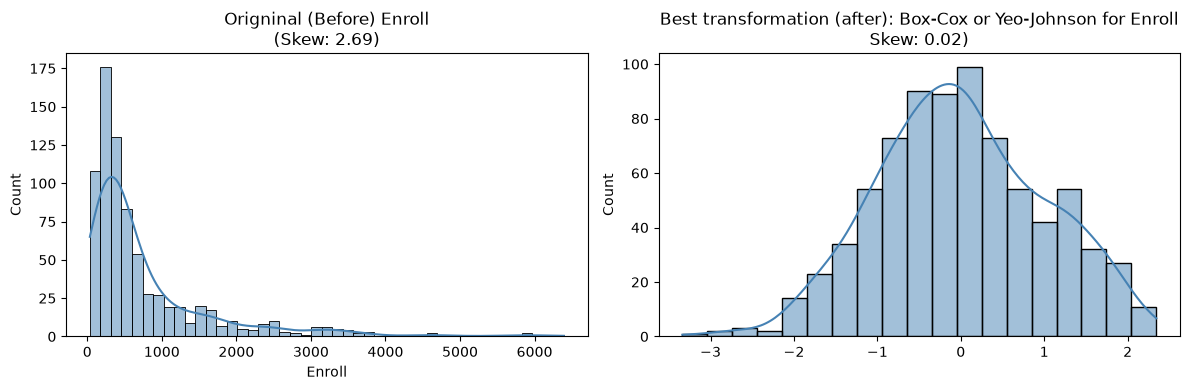

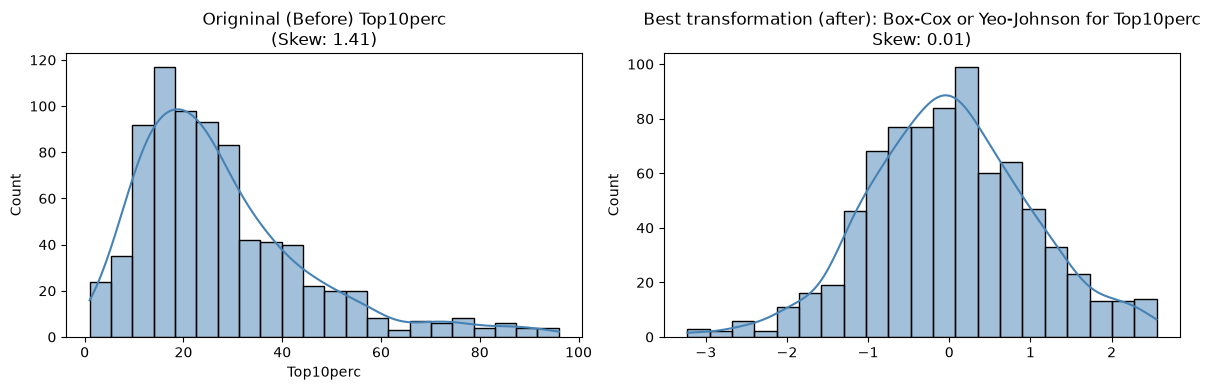

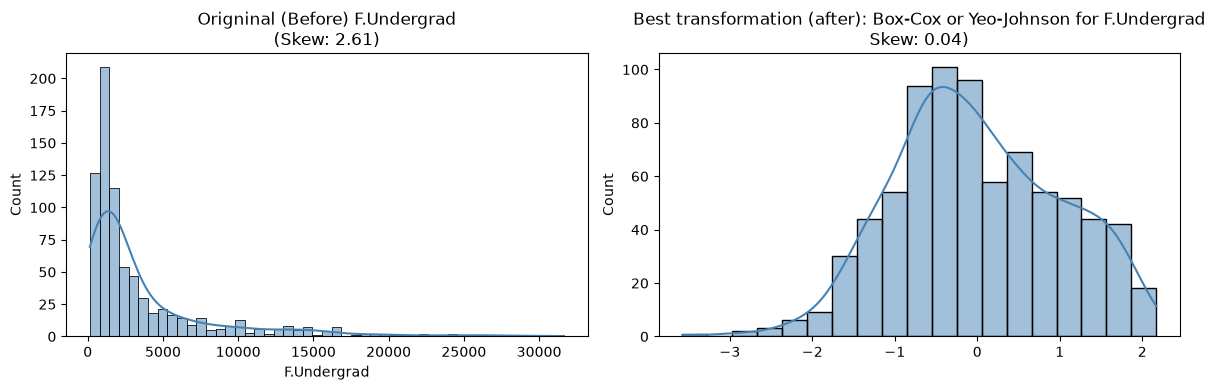

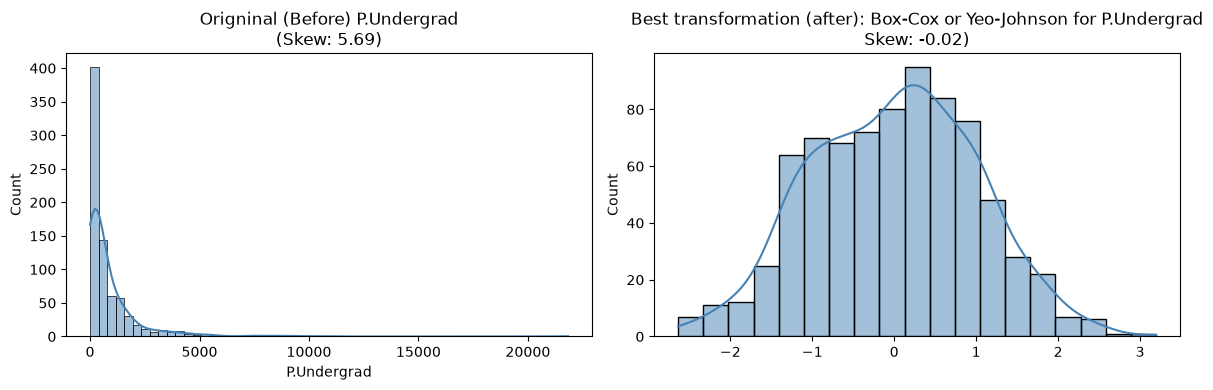

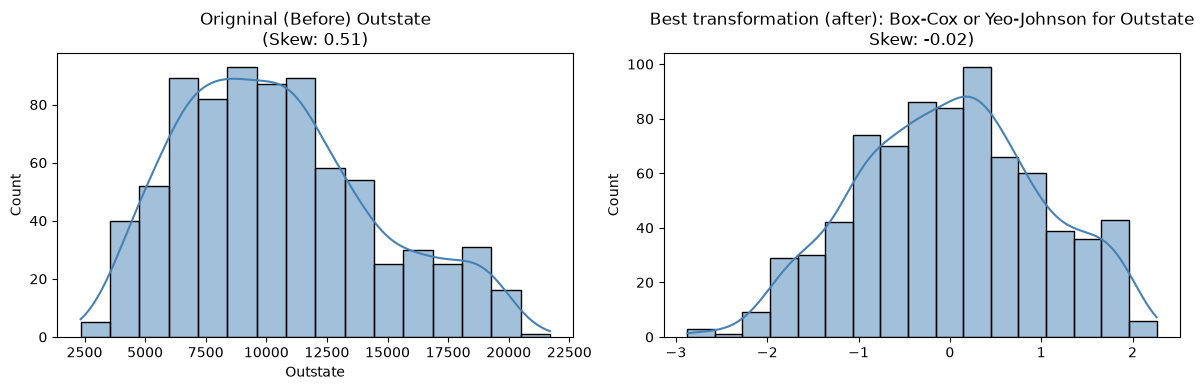

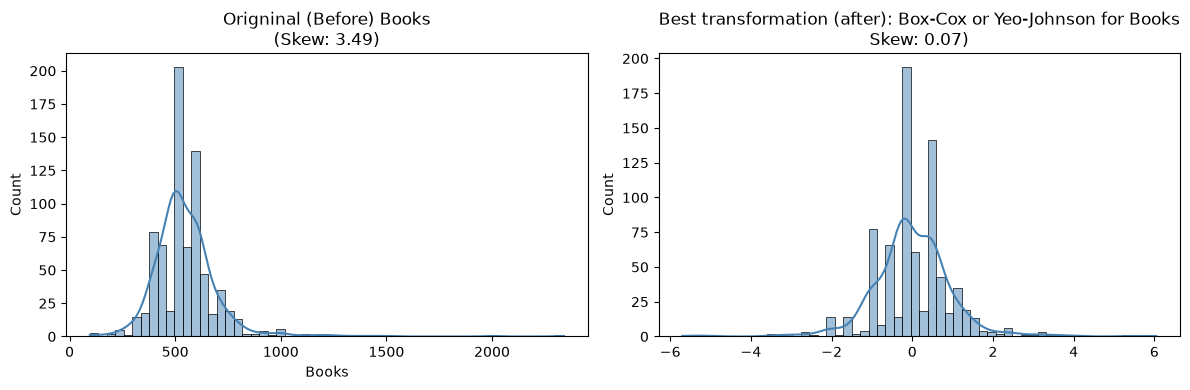

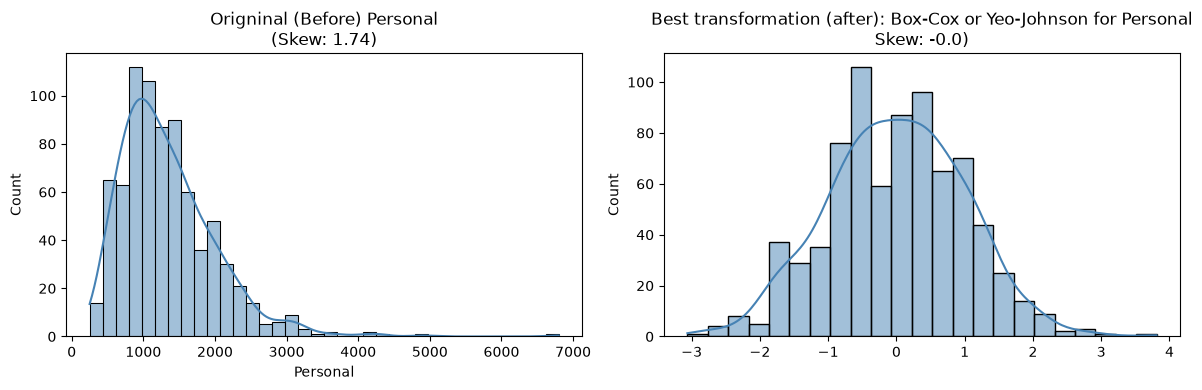

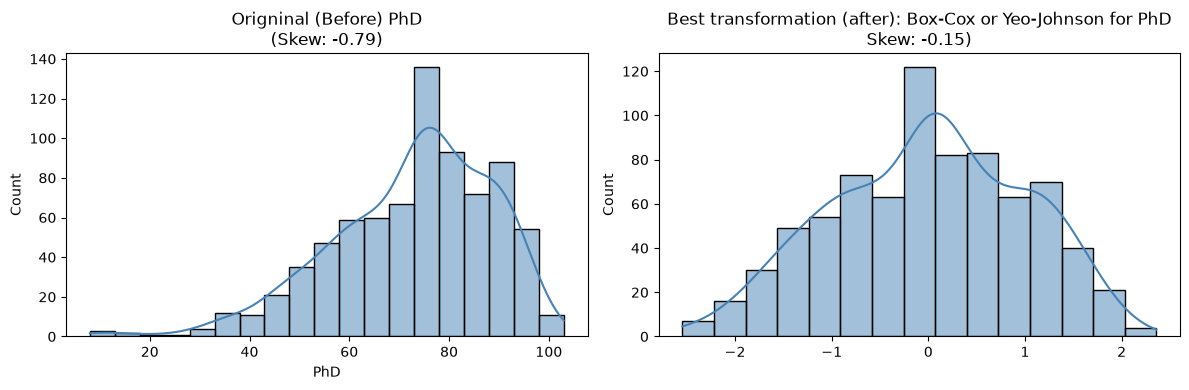

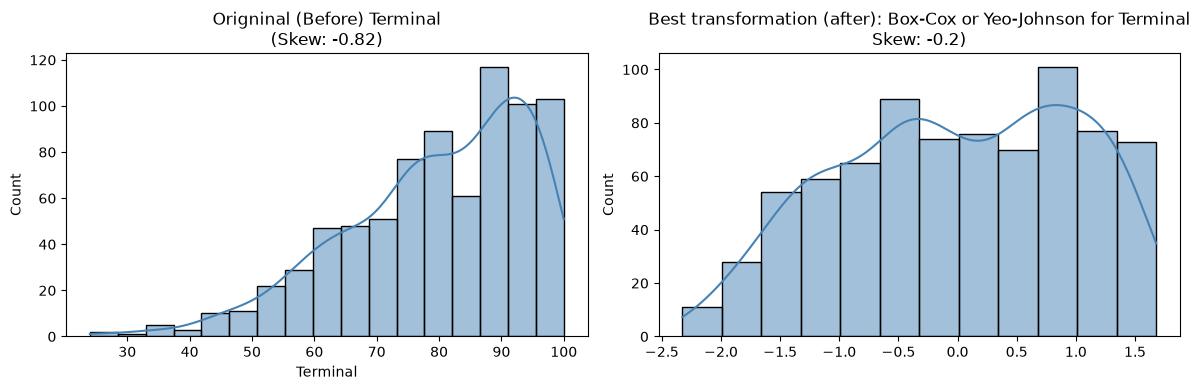

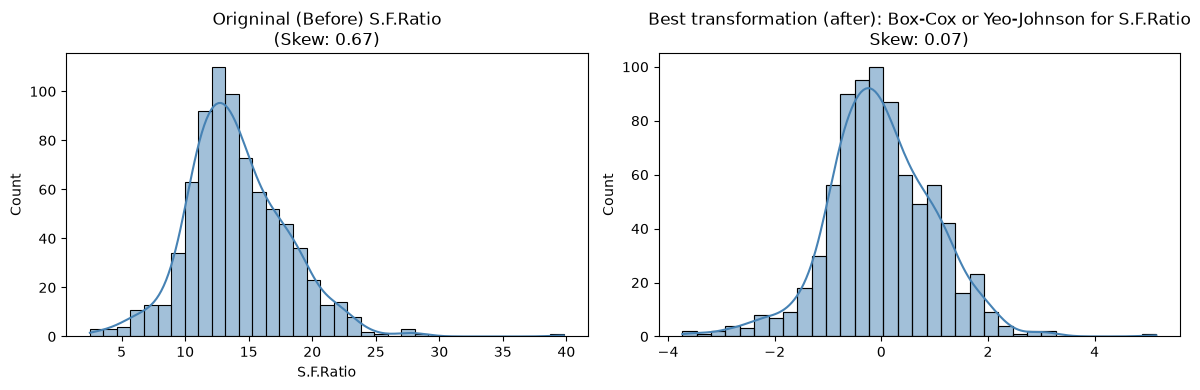

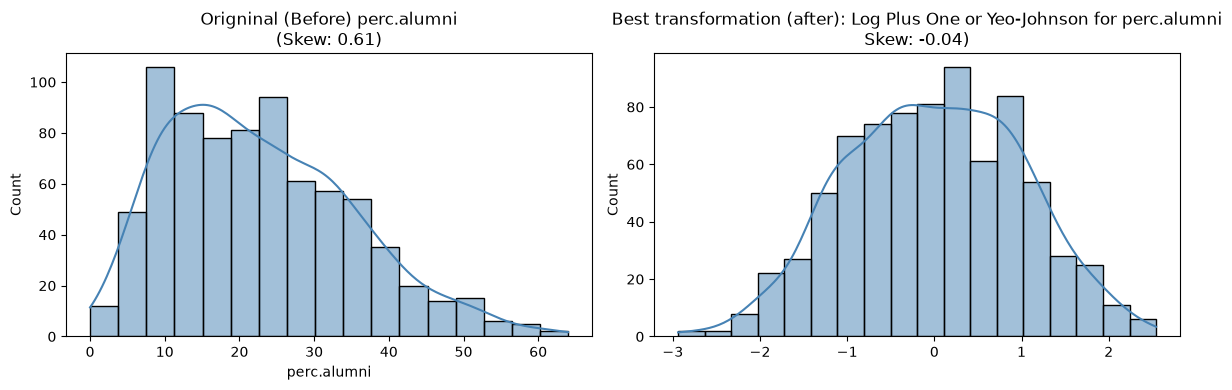

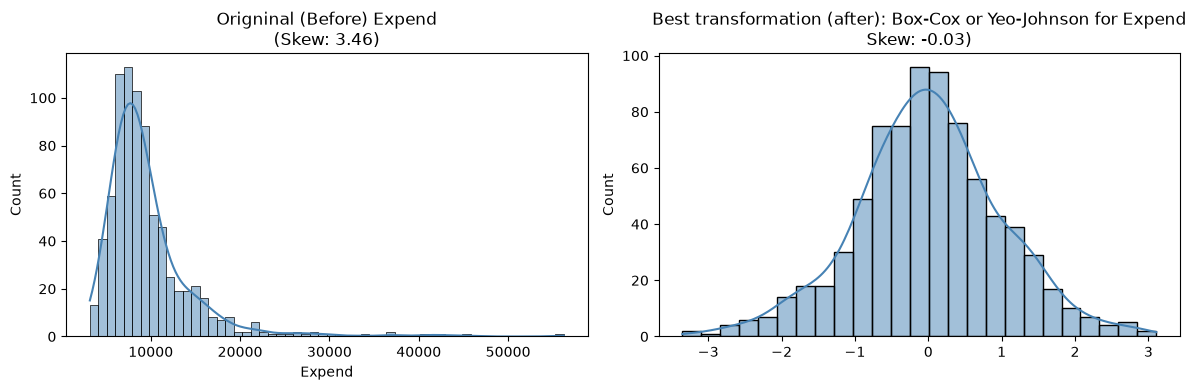

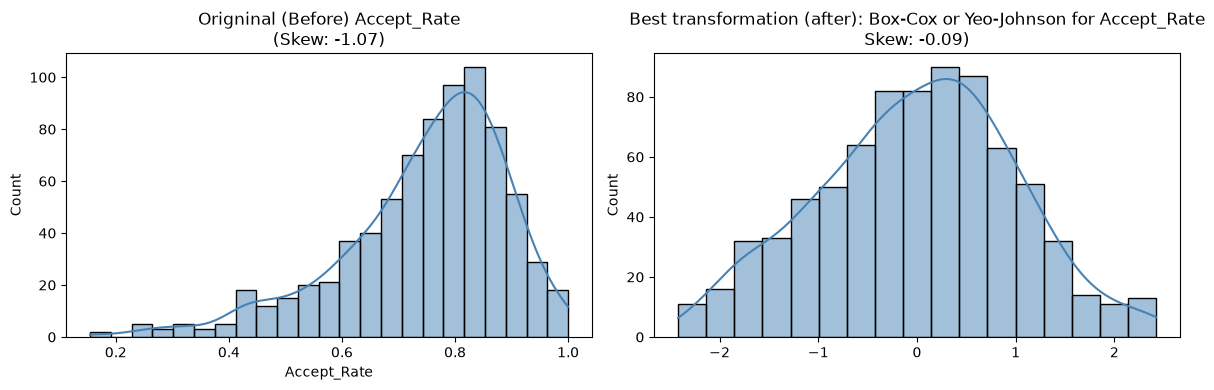

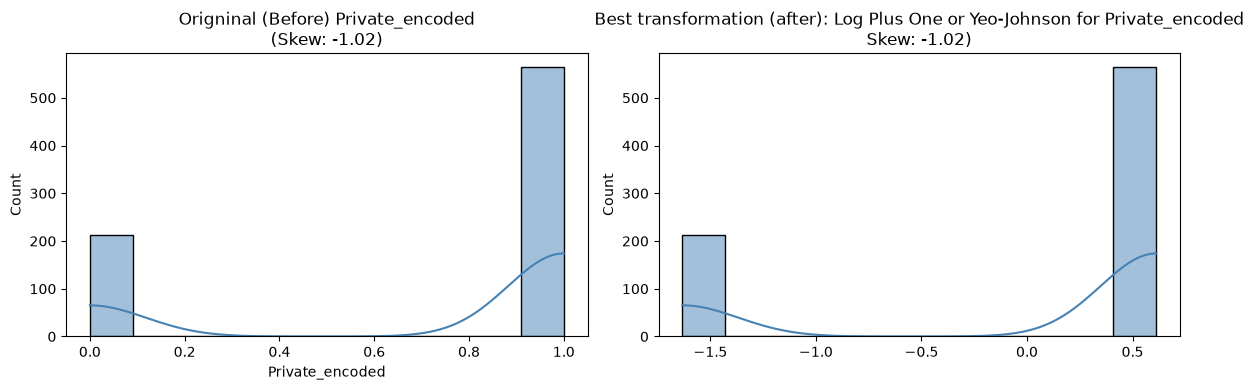

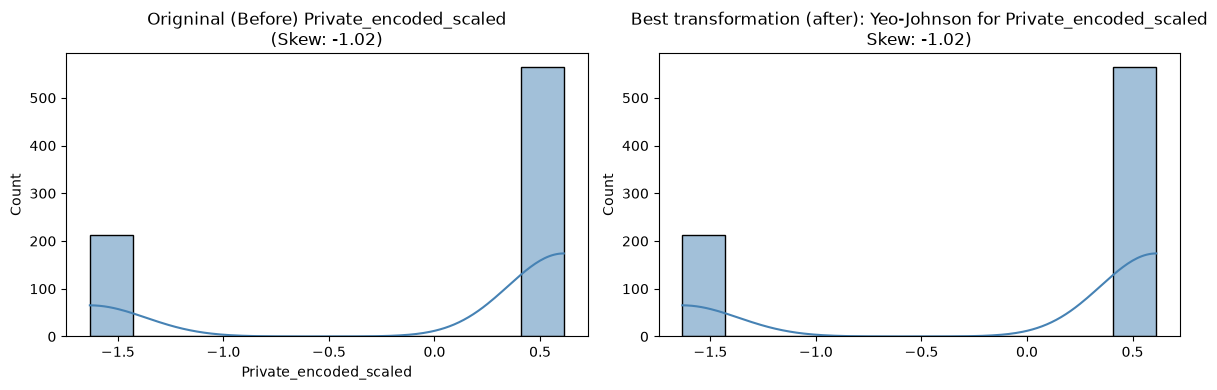

In [69]:
plot_transformations(college, skew_table)

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [70]:
# Your code here
skew_table = skew_calc(college)
skew_table

,feature,skewness,degree,direction,recommended trans
0,Apps,3.723750,Highly Skewed,Right,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Right,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Right,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Right,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Normal,Symmetrical,None
5,F.Undergrad,2.610458,Highly Skewed,Right,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Right,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Right,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Normal,Symmetrical,None
9,Books,3.485025,Highly Skewed,Right,Box-Cox or Yeo-Johnson


In [71]:
# Your code here

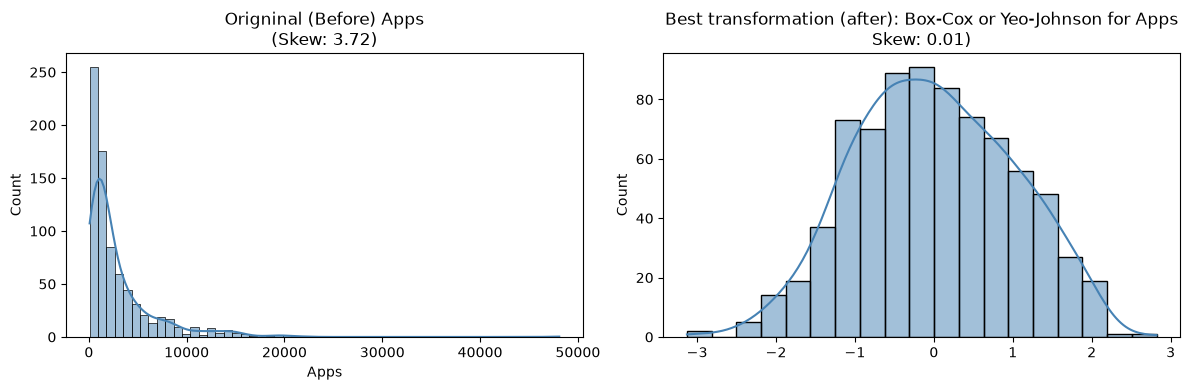

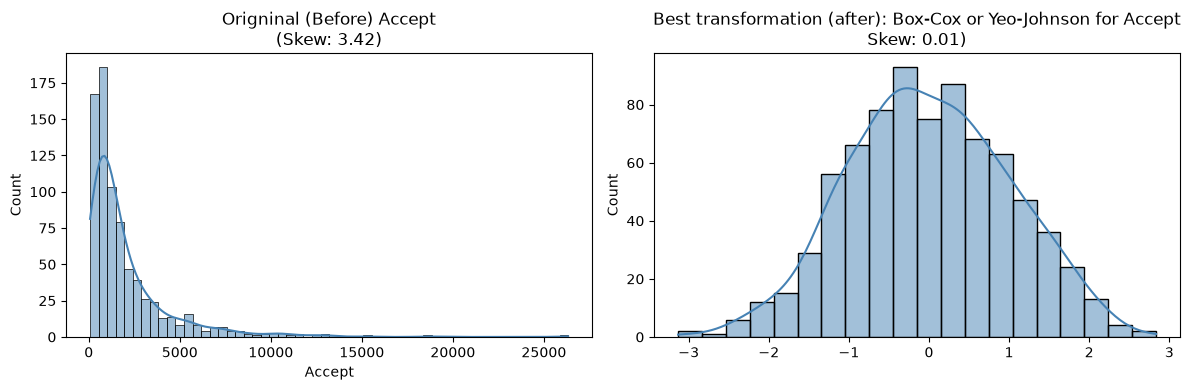

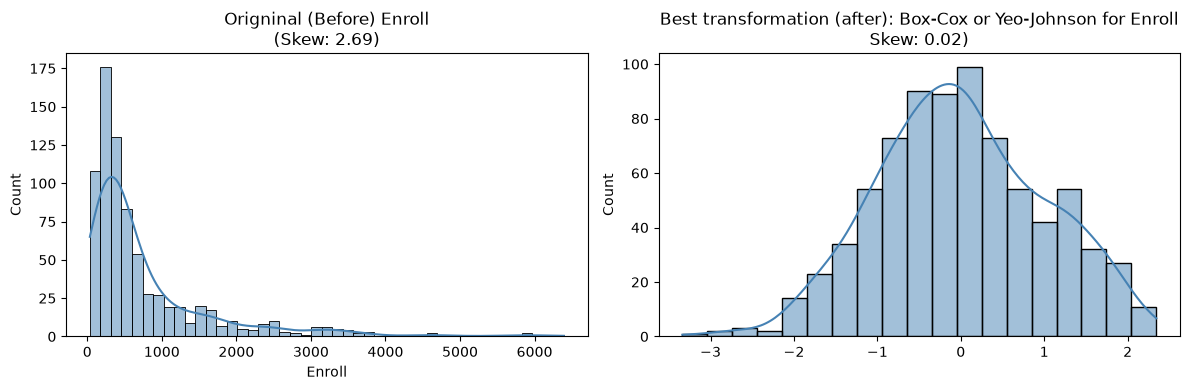

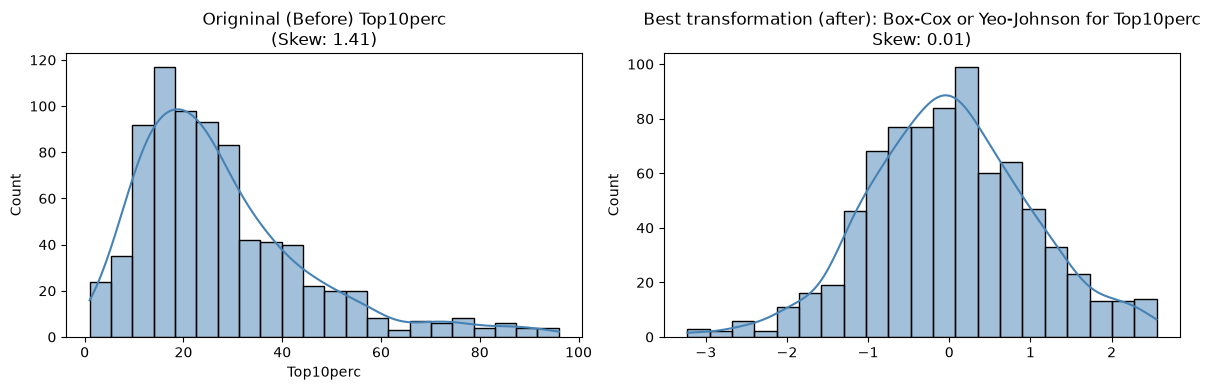

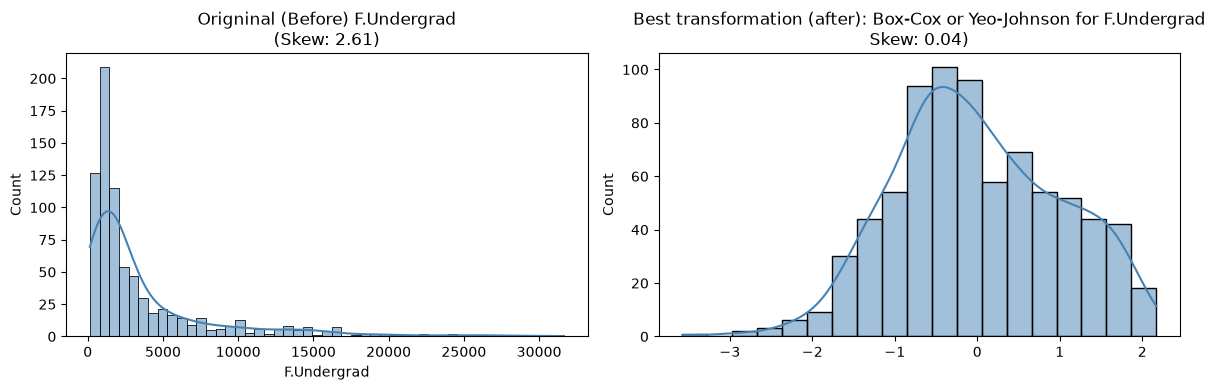

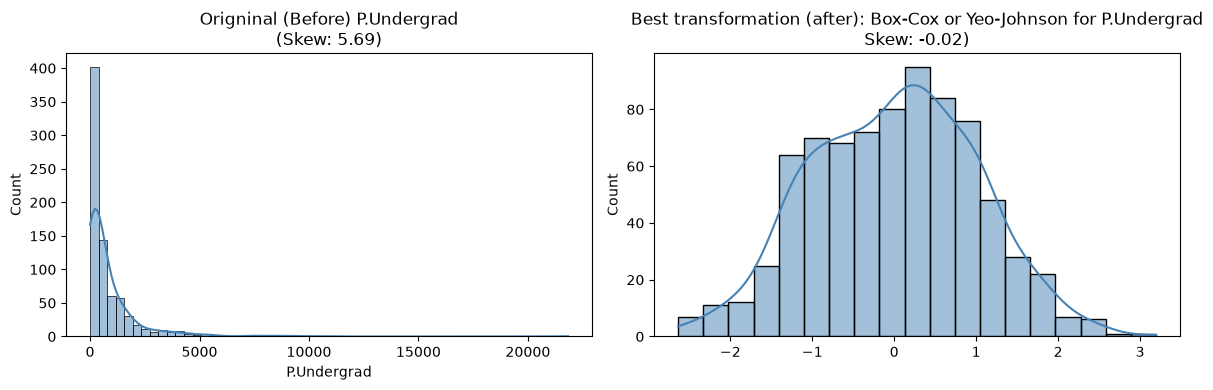

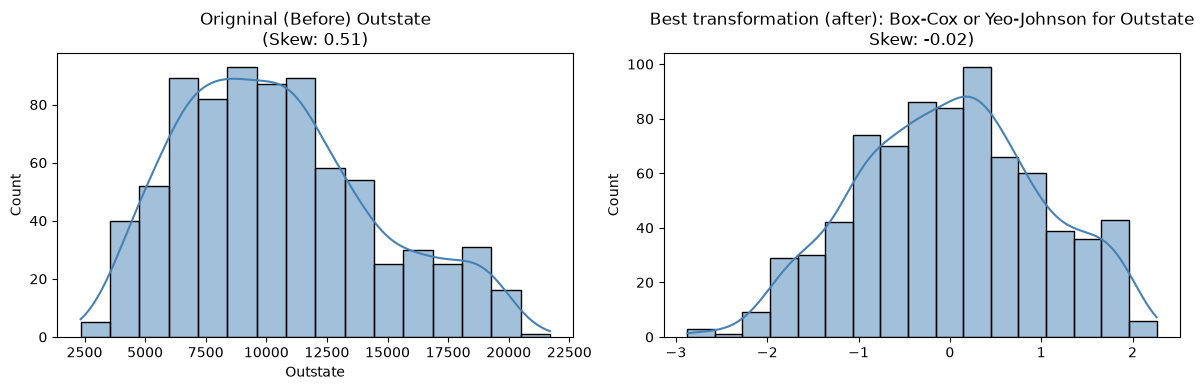

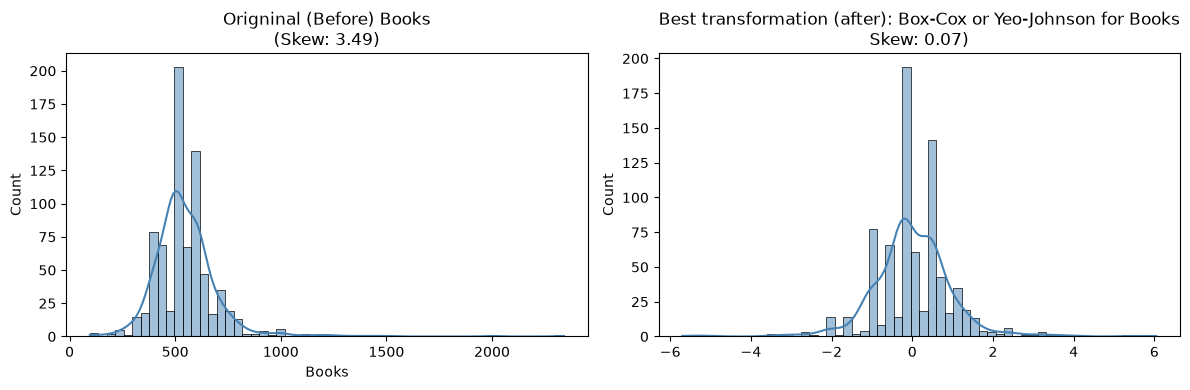

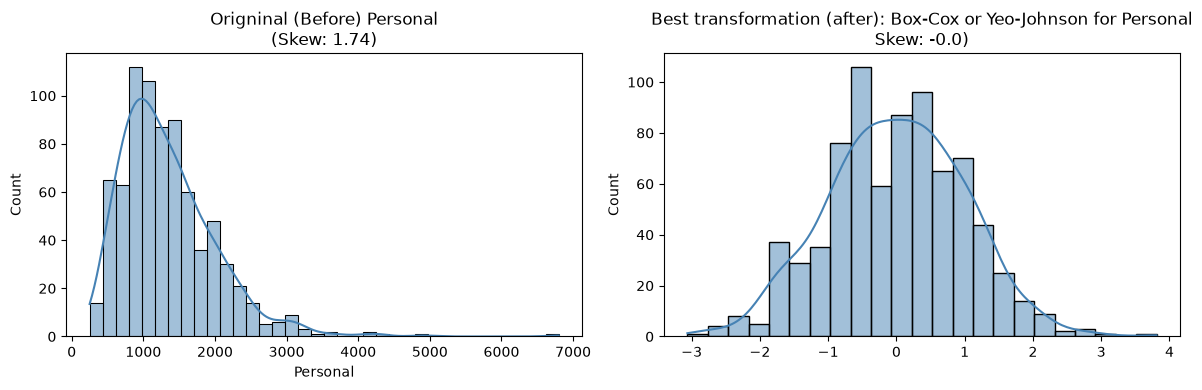

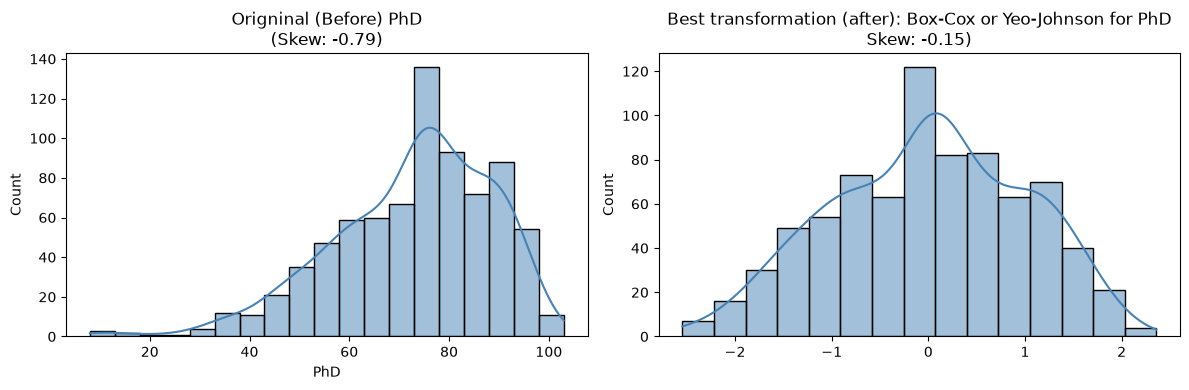

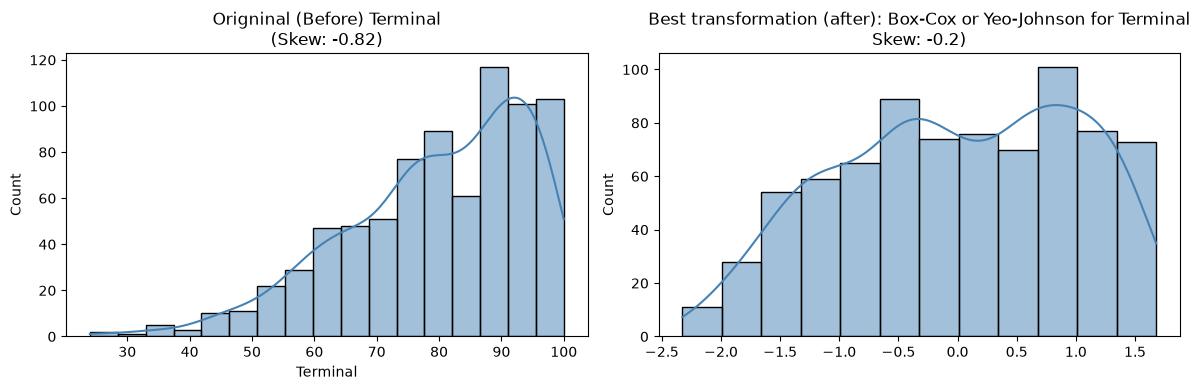

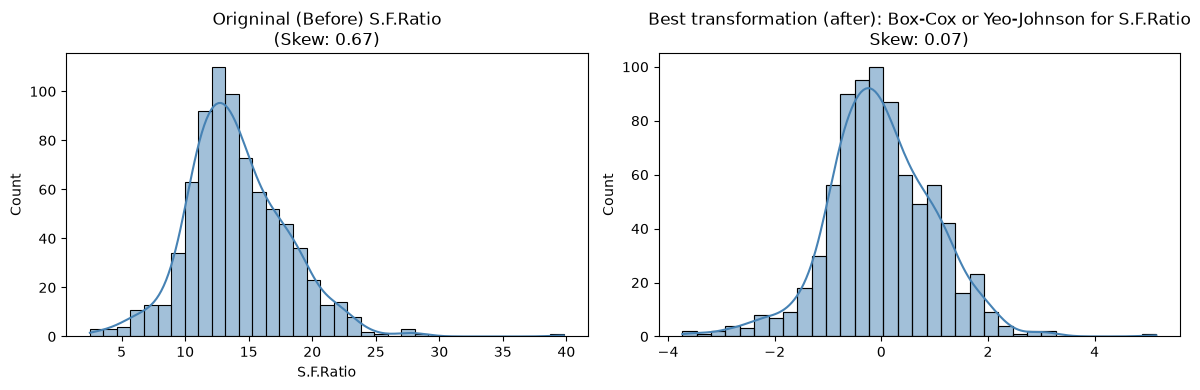

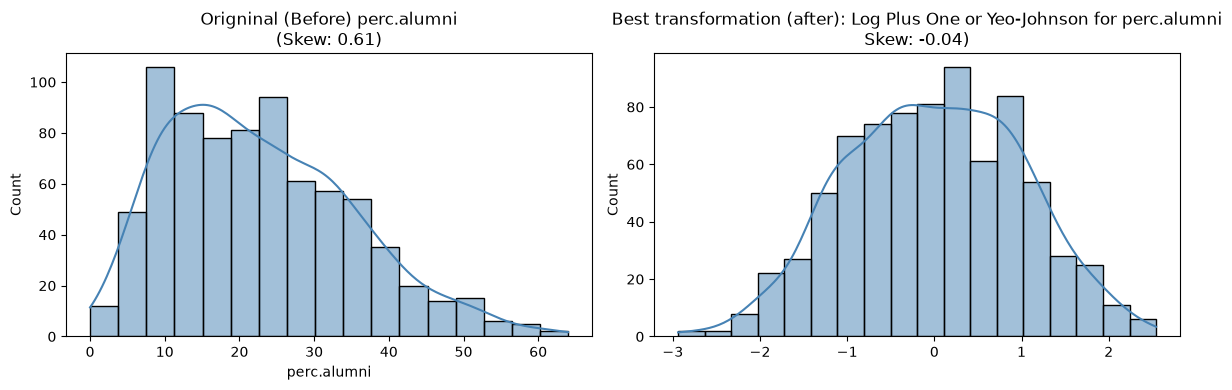

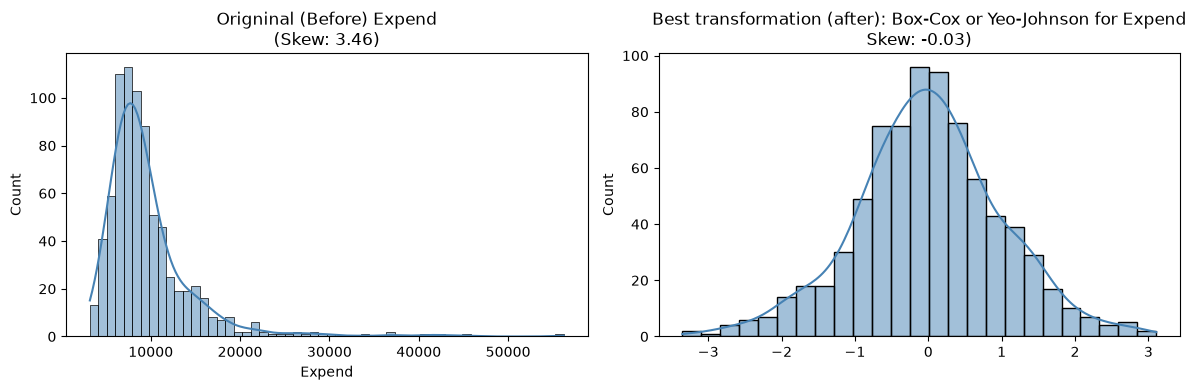

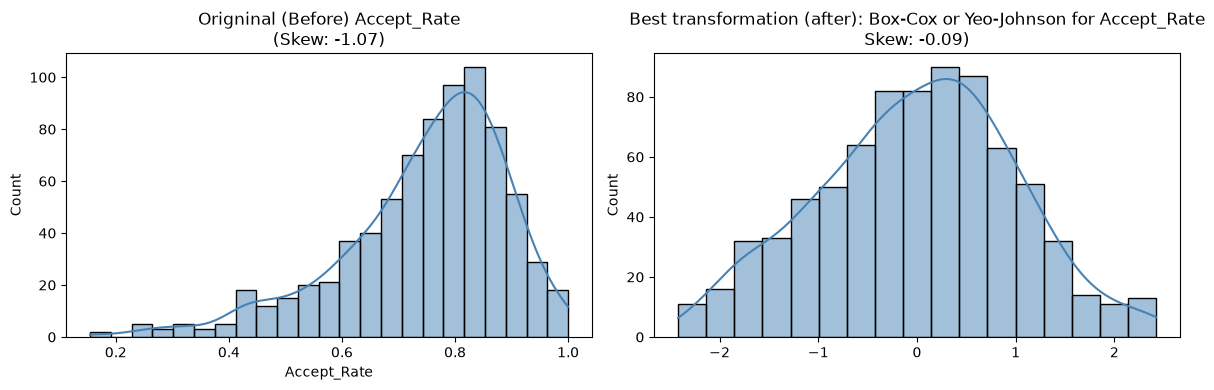

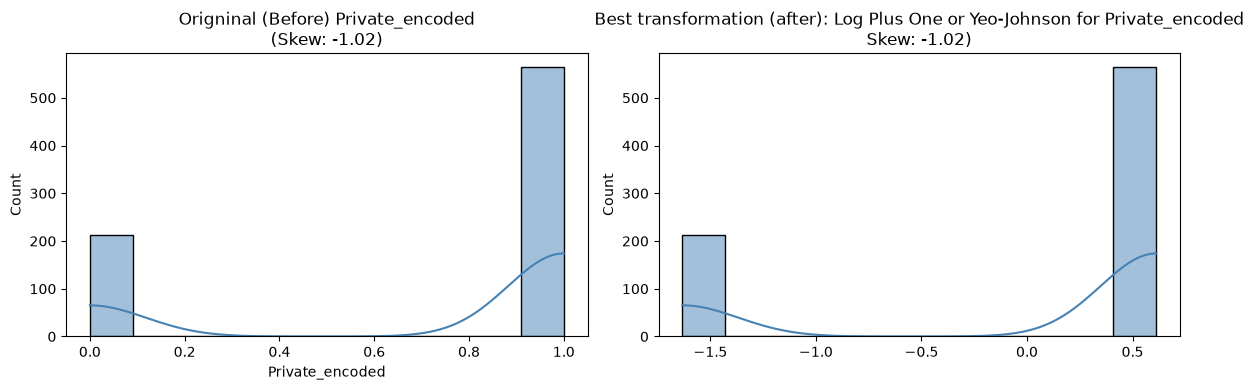

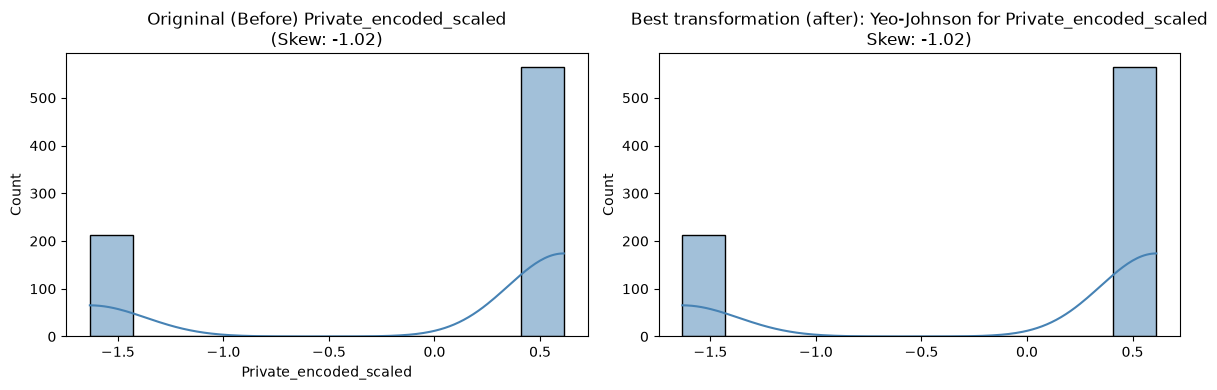

In [72]:
# Your code here
plot_transformations(college, skew_table)

In [73]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [74]:
trans_cols = []

to_transform = skew_table[skew_table["recommended trans"] != "None"]

for _, row in to_transform.iterrows():
    col_name = row["feature"]
    method = row["recommended trans"]
    original = college[col_name].dropna()
    new_col_name = f"{col_name}_trans"

    if 'Yeo-Johnson' in method:
        pt_yeo = PowerTransformer(method='yeo-johnson')
        college[new_col_name] = pt_yeo.fit_transform(college[[col_name]])
        
    elif 'Log Plus One' in method:
        college[new_col_name] = np.log1p(college[col_name])

    elif 'Box-Cox' in method:
        pt_boxcox = PowerTransformer(method='box-cox')
        college[new_col_name] = pt_boxcox.fit_transform(college[[col_name]])

    trans_cols.append(new_col_name)

college[trans_cols].head()
# Your code here 

,Apps_trans,Accept_trans,Enroll_trans,Top10perc_trans,F.Undergrad_trans,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans,Accept_Rate_trans,Private_encoded_trans,Private_encoded_scaled_trans
0,0.027875,0.041123,0.493988,-0.047533,0.433757,0.306487,-0.693452,-0.614325,1.271442,-0.291583,-0.282856,1.019033,-0.834712,-0.491190,-0.218656,0.612553,0.612553
1,0.283085,0.486070,0.142540,-0.586896,0.365526,0.873163,0.556270,1.302507,0.456594,-2.176663,-2.247872,-0.434462,-0.432329,0.552370,1.003336,0.612553,0.612553
2,-0.113891,-0.077005,-0.316177,-0.116099,-0.636916,-0.731646,0.322012,-1.038801,-0.068655,-1.261658,-1.040649,-0.249057,0.674492,0.096393,-0.017425,0.612553,0.612553
3,-1.333051,-1.294811,-1.397108,1.609115,-1.531331,-0.982726,0.703928,-0.614325,-0.651789,1.362198,1.365157,-1.747012,1.125798,1.727003,0.577595,0.612553,0.612553
4,-2.152336,-2.286486,-2.653827,-0.586896,-2.587702,0.631619,-0.656779,1.553695,0.456594,0.114804,-0.687317,-0.515219,-2.329357,0.637052,-0.109648,0.612553,0.612553


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [75]:
# Your code here 
college['Accept_Rate'] =  college['Accept'] / college['Apps']
college['Accept_Rate'].describe()

count    777.000000
mean       0.746928
std        0.147104
min        0.154486
25%        0.675647
50%        0.778750
75%        0.848522
max        1.000000
Name: Accept_Rate, dtype: float64

#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [76]:
# Your code here 
college['Outstate_Tier'] = pd.cut(x= college['Outstate'], bins = 3, labels = ['Low', 'Medium', 'High'])

In [77]:
college['Outstate_Tier'].value_counts()

Outstate_Tier
Medium    364
Low       302
High      111
Name: count, dtype: int64

#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [78]:
# Your code here 
tier_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'Very High': 3
}

college['Outstate_Tier_encoded'] = college['Outstate_Tier'].map(tier_mapping)
college['Outstate_Tier_encoded'].value_counts()

Outstate_Tier_encoded
1    364
0    302
2    111
Name: count, dtype: int64

#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [79]:
# Your code here 
college['Private_encoded'] = college['Private'].map({'Yes': 1, 'No': 0})

college['Private_encoded'].value_counts()

Private_encoded
1    565
0    212
Name: count, dtype: int64

## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [80]:
cols_to_scale = ['Outstate_Tier_encoded', 'Private_encoded'] +trans_cols 
cols_to_scale
# Your code here 

['Outstate_Tier_encoded',
 'Private_encoded',
 'Apps_trans',
 'Accept_trans',
 'Enroll_trans',
 'Top10perc_trans',
 'F.Undergrad_trans',
 'P.Undergrad_trans',
 'Outstate_trans',
 'Books_trans',
 'Personal_trans',
 'PhD_trans',
 'Terminal_trans',
 'S.F.Ratio_trans',
 'perc.alumni_trans',
 'Expend_trans',
 'Accept_Rate_trans',
 'Private_encoded_trans',
 'Private_encoded_scaled_trans']

In [81]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(college[cols_to_scale])

scaled_col_names = [f"{col}_scaled" for col in cols_to_scale]
college[scaled_col_names] = pd.DataFrame(scaled_values, columns=scaled_col_names, index=college.index)

college[scaled_col_names].head()

,Outstate_Tier_encoded_scaled,Private_encoded_scaled,Apps_trans_scaled,Accept_trans_scaled,Enroll_trans_scaled,Top10perc_trans_scaled,F.Undergrad_trans_scaled,P.Undergrad_trans_scaled,Outstate_trans_scaled,Books_trans_scaled,Personal_trans_scaled,PhD_trans_scaled,Terminal_trans_scaled,S.F.Ratio_trans_scaled,perc.alumni_trans_scaled,Expend_trans_scaled,Accept_Rate_trans_scaled,Private_encoded_trans_scaled,Private_encoded_scaled_trans_scaled
0,-1.098797,0.612553,0.027875,0.041123,0.493988,-0.047533,0.433757,0.306487,-0.693452,-0.614325,1.271442,-0.291583,-0.282856,1.019033,-0.834712,-0.491190,-0.218656,0.612553,0.612553
1,0.358140,0.612553,0.283085,0.486070,0.142540,-0.586896,0.365526,0.873163,0.556270,1.302507,0.456594,-2.176663,-2.247872,-0.434462,-0.432329,0.552370,1.003336,0.612553,0.612553
2,0.358140,0.612553,-0.113891,-0.077005,-0.316177,-0.116099,-0.636916,-0.731646,0.322012,-1.038801,-0.068655,-1.261658,-1.040649,-0.249057,0.674492,0.096393,-0.017425,0.612553,0.612553
3,0.358140,0.612553,-1.333051,-1.294811,-1.397108,1.609115,-1.531331,-0.982726,0.703928,-0.614325,-0.651789,1.362198,1.365157,-1.747012,1.125798,1.727003,0.577595,0.612553,0.612553
4,-1.098797,0.612553,-2.152336,-2.286486,-2.653827,-0.586896,-2.587702,0.631619,-0.656779,1.553695,0.456594,0.114804,-0.687317,-0.515219,-2.329357,0.637052,-0.109648,0.612553,0.612553


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

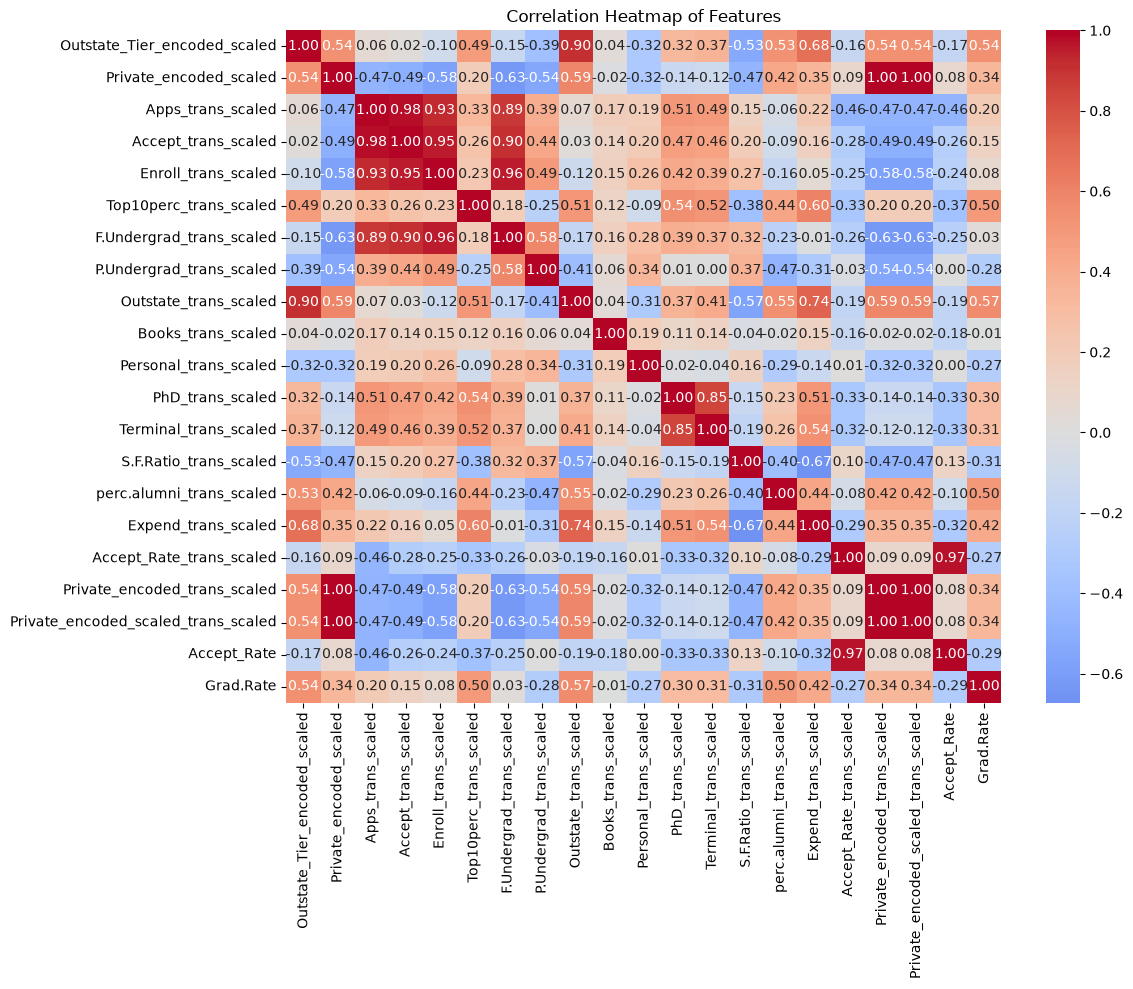

In [82]:
# Your code here 
heatmap_cols = scaled_col_names + ['Accept_Rate', 'Grad.Rate']

corr_matrix = college[heatmap_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()


In [83]:
corr_matrix['Grad.Rate'].sort_values(ascending=False)

Grad.Rate                              1.000000
Outstate_trans_scaled                  0.569032
Outstate_Tier_encoded_scaled           0.538930
perc.alumni_trans_scaled               0.500899
Top10perc_trans_scaled                 0.495057
Expend_trans_scaled                    0.417199
Private_encoded_trans_scaled           0.336490
Private_encoded_scaled_trans_scaled    0.336490
Private_encoded_scaled                 0.336490
Terminal_trans_scaled                  0.310558
PhD_trans_scaled                       0.303732
Apps_trans_scaled                      0.202305
Accept_trans_scaled                    0.147992
Enroll_trans_scaled                    0.078218
F.Undergrad_trans_scaled               0.033351
Books_trans_scaled                    -0.005477
Accept_Rate_trans_scaled              -0.267819
Personal_trans_scaled                 -0.269857
P.Undergrad_trans_scaled              -0.277715
Accept_Rate                           -0.289299
S.F.Ratio_trans_scaled                -0

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [84]:
trans_cols

['Apps_trans',
 'Accept_trans',
 'Enroll_trans',
 'Top10perc_trans',
 'F.Undergrad_trans',
 'P.Undergrad_trans',
 'Outstate_trans',
 'Books_trans',
 'Personal_trans',
 'PhD_trans',
 'Terminal_trans',
 'S.F.Ratio_trans',
 'perc.alumni_trans',
 'Expend_trans',
 'Accept_Rate_trans',
 'Private_encoded_trans',
 'Private_encoded_scaled_trans']

In [85]:
cols_untrans_raw = ['Apps', 'Accept', 'Enroll', 'Top10perc', 'F.Undergrad', 'P.Undergrad',
                     'Outstate', 'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio',
                     'perc.alumni', 'Expend']

X_untrans = college[cols_untrans_raw]
y = college['Grad.Rate']

X_train_untrans, X_test_untrans, y_train_untrans, y_test_untrans = train_test_split(X_untrans, y, test_size=0.2, random_state=1)

In [86]:
scaled_col_names

['Outstate_Tier_encoded_scaled',
 'Private_encoded_scaled',
 'Apps_trans_scaled',
 'Accept_trans_scaled',
 'Enroll_trans_scaled',
 'Top10perc_trans_scaled',
 'F.Undergrad_trans_scaled',
 'P.Undergrad_trans_scaled',
 'Outstate_trans_scaled',
 'Books_trans_scaled',
 'Personal_trans_scaled',
 'PhD_trans_scaled',
 'Terminal_trans_scaled',
 'S.F.Ratio_trans_scaled',
 'perc.alumni_trans_scaled',
 'Expend_trans_scaled',
 'Accept_Rate_trans_scaled',
 'Private_encoded_trans_scaled',
 'Private_encoded_scaled_trans_scaled']

In [87]:
cols_trans = ['Outstate_Tier_encoded_scaled',
 'Private_encoded_scaled',
 'Apps_trans_scaled',
 'Accept_trans_scaled',
 'Enroll_trans_scaled',
 'Top10perc_trans_scaled',
 'F.Undergrad_trans_scaled',
 'P.Undergrad_trans_scaled',
 'Outstate_trans_scaled',
 'Books_trans_scaled',
 'Personal_trans_scaled',
 'PhD_trans_scaled',
 'Terminal_trans_scaled',
 'S.F.Ratio_trans_scaled',
 'perc.alumni_trans_scaled',
 'Expend_trans_scaled']

y= college['Grad.Rate']
X_trans = college[cols_trans]

X_train_trans, X_test_trans, y_train_trans, y_test_trans = train_test_split(X_trans, y,  test_size =0.2, random_state= 1)

#### 15. Fit a linear regression using the raw predictors


In [90]:
mlr_untrans = LinearRegression()
mlr_untrans.fit(X_train_untrans, y_train_untrans)

y_pred_train_untrans = mlr_untrans.predict(X_train_untrans)
y_pred_test_untrans = mlr_untrans.predict(X_test_untrans)


r2_train = r2_score(y_train_untrans, y_pred_train_untrans)
r2_test = r2_score(y_test_untrans, y_pred_test_untrans)

print("Untransformed train R2:", r2_train)
print("Untransformed test R2:", r2_test)

Untransformed train R2: 0.4420744200860751
Untransformed test R2: 0.45774311165105563


#### 16. Fit the same model using the log-transformed predictors

In [91]:
model_trans = LinearRegression()
model_trans.fit(X_train_trans, y_train_trans)

y_pred_train_trans = model_trans.predict(X_train_trans)
y_pred_test_trans = model_trans.predict(X_test_trans)

r2_train = r2_score(y_train_trans, y_pred_train_trans)
r2_test = r2_score(y_test_trans, y_pred_test_trans)

print('Transformed train R2:', r2_train)
print('Transformed test R2:', r2_test)

Transformed train R2: 0.4695059302459268
Transformed test R2: 0.48476284869583885


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [92]:
# Your code here 
college.to_csv('college_transformed.csv', index=False)